# Celebal Technologies Assignment 2

## End-to-End Machine Learning Pipeline on Tesla Deliveries Dataset (2015–2025)

---

**Student:** Onkar Anil Gunjal  
**Notebook:** Week 2 Assignment  
**Date:** June 2025

---

### Objective

The goal of this assignment is to build a complete machine learning pipeline on Tesla's global delivery dataset (2015–2025). We will go through all the key steps: loading and exploring the data, handling missing values, feature engineering, chronological train-test splitting, training regression models, performing cross validation, hyperparameter tuning with GridSearchCV, stationarity testing with ADF, and finally comparing models and drawing conclusions.


In [1]:
# ─────────────────────────────────────────────
# Cell 1 – Import all required libraries
# ─────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')   # suppress noisy warnings throughout the notebook

# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model selection & evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time-series stationarity test
from statsmodels.tsa.stattools import adfuller

# Set a consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully.")


All libraries imported successfully.


## Section 1 – Loading and Understanding the Dataset

Before we do any analysis or modelling, we need to load the data and get a feel for what it contains. This means looking at the shape, column names, data types, and some basic statistics. It helps us spot potential issues early — like wrong data types, unexpected ranges, or columns we need to engineer later.


In [2]:
# ─────────────────────────────────────────────
# Cell 2 – Load the dataset and inspect it
# ─────────────────────────────────────────────

# Load the CSV file
df = pd.read_csv('tesla_deliveries_dataset_2015_2025 2.csv')

# Basic shape information
print(f"Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns\n")

# Column names
print("Column Names:")
print(list(df.columns))
print()

# Data types and non-null counts
print("Dataset Info:")
df.info()
print()

# Summary statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe().round(2))

# First five rows
print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape : 2640 rows × 12 columns

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type        

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00



First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Section 2 – Checking Missing Values and Duplicates

Missing values and duplicate rows can silently hurt model performance. If a column has a lot of missing values, we might need to impute or drop it. Duplicates can cause the model to overfit on repeated data. Catching these issues at the start saves a lot of headaches later.


In [3]:
# ─────────────────────────────────────────────
# Cell 3 – Missing values and duplicate check
# ─────────────────────────────────────────────

# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})

print("Missing Value Summary:")
display(missing_df)

# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {dup_count}")

if dup_count == 0:
    print("Great – no duplicate rows found. The dataset is clean.")
else:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{dup_count} duplicate rows removed. New shape: {df.shape}")


Missing Value Summary:


,Missing Count,Missing %
Year,0,0.0
Month,0,0.0
Region,0,0.0
Model,0,0.0
Estimated_Deliveries,0,0.0
Production_Units,0,0.0
Avg_Price_USD,0,0.0
Battery_Capacity_kWh,0,0.0
Range_km,0,0.0
CO2_Saved_tons,0,0.0



Number of Duplicate Rows: 0
Great – no duplicate rows found. The dataset is clean.


## Section 3 – Exploratory Data Analysis (EDA)

EDA is all about understanding the patterns, distributions, and relationships in the data before touching any models. We use charts to get quick visual summaries. For example, a bar chart can tell us which Tesla model was delivered the most, while a correlation heatmap shows us how strongly different features are related to each other. These insights guide us during feature selection and model building.


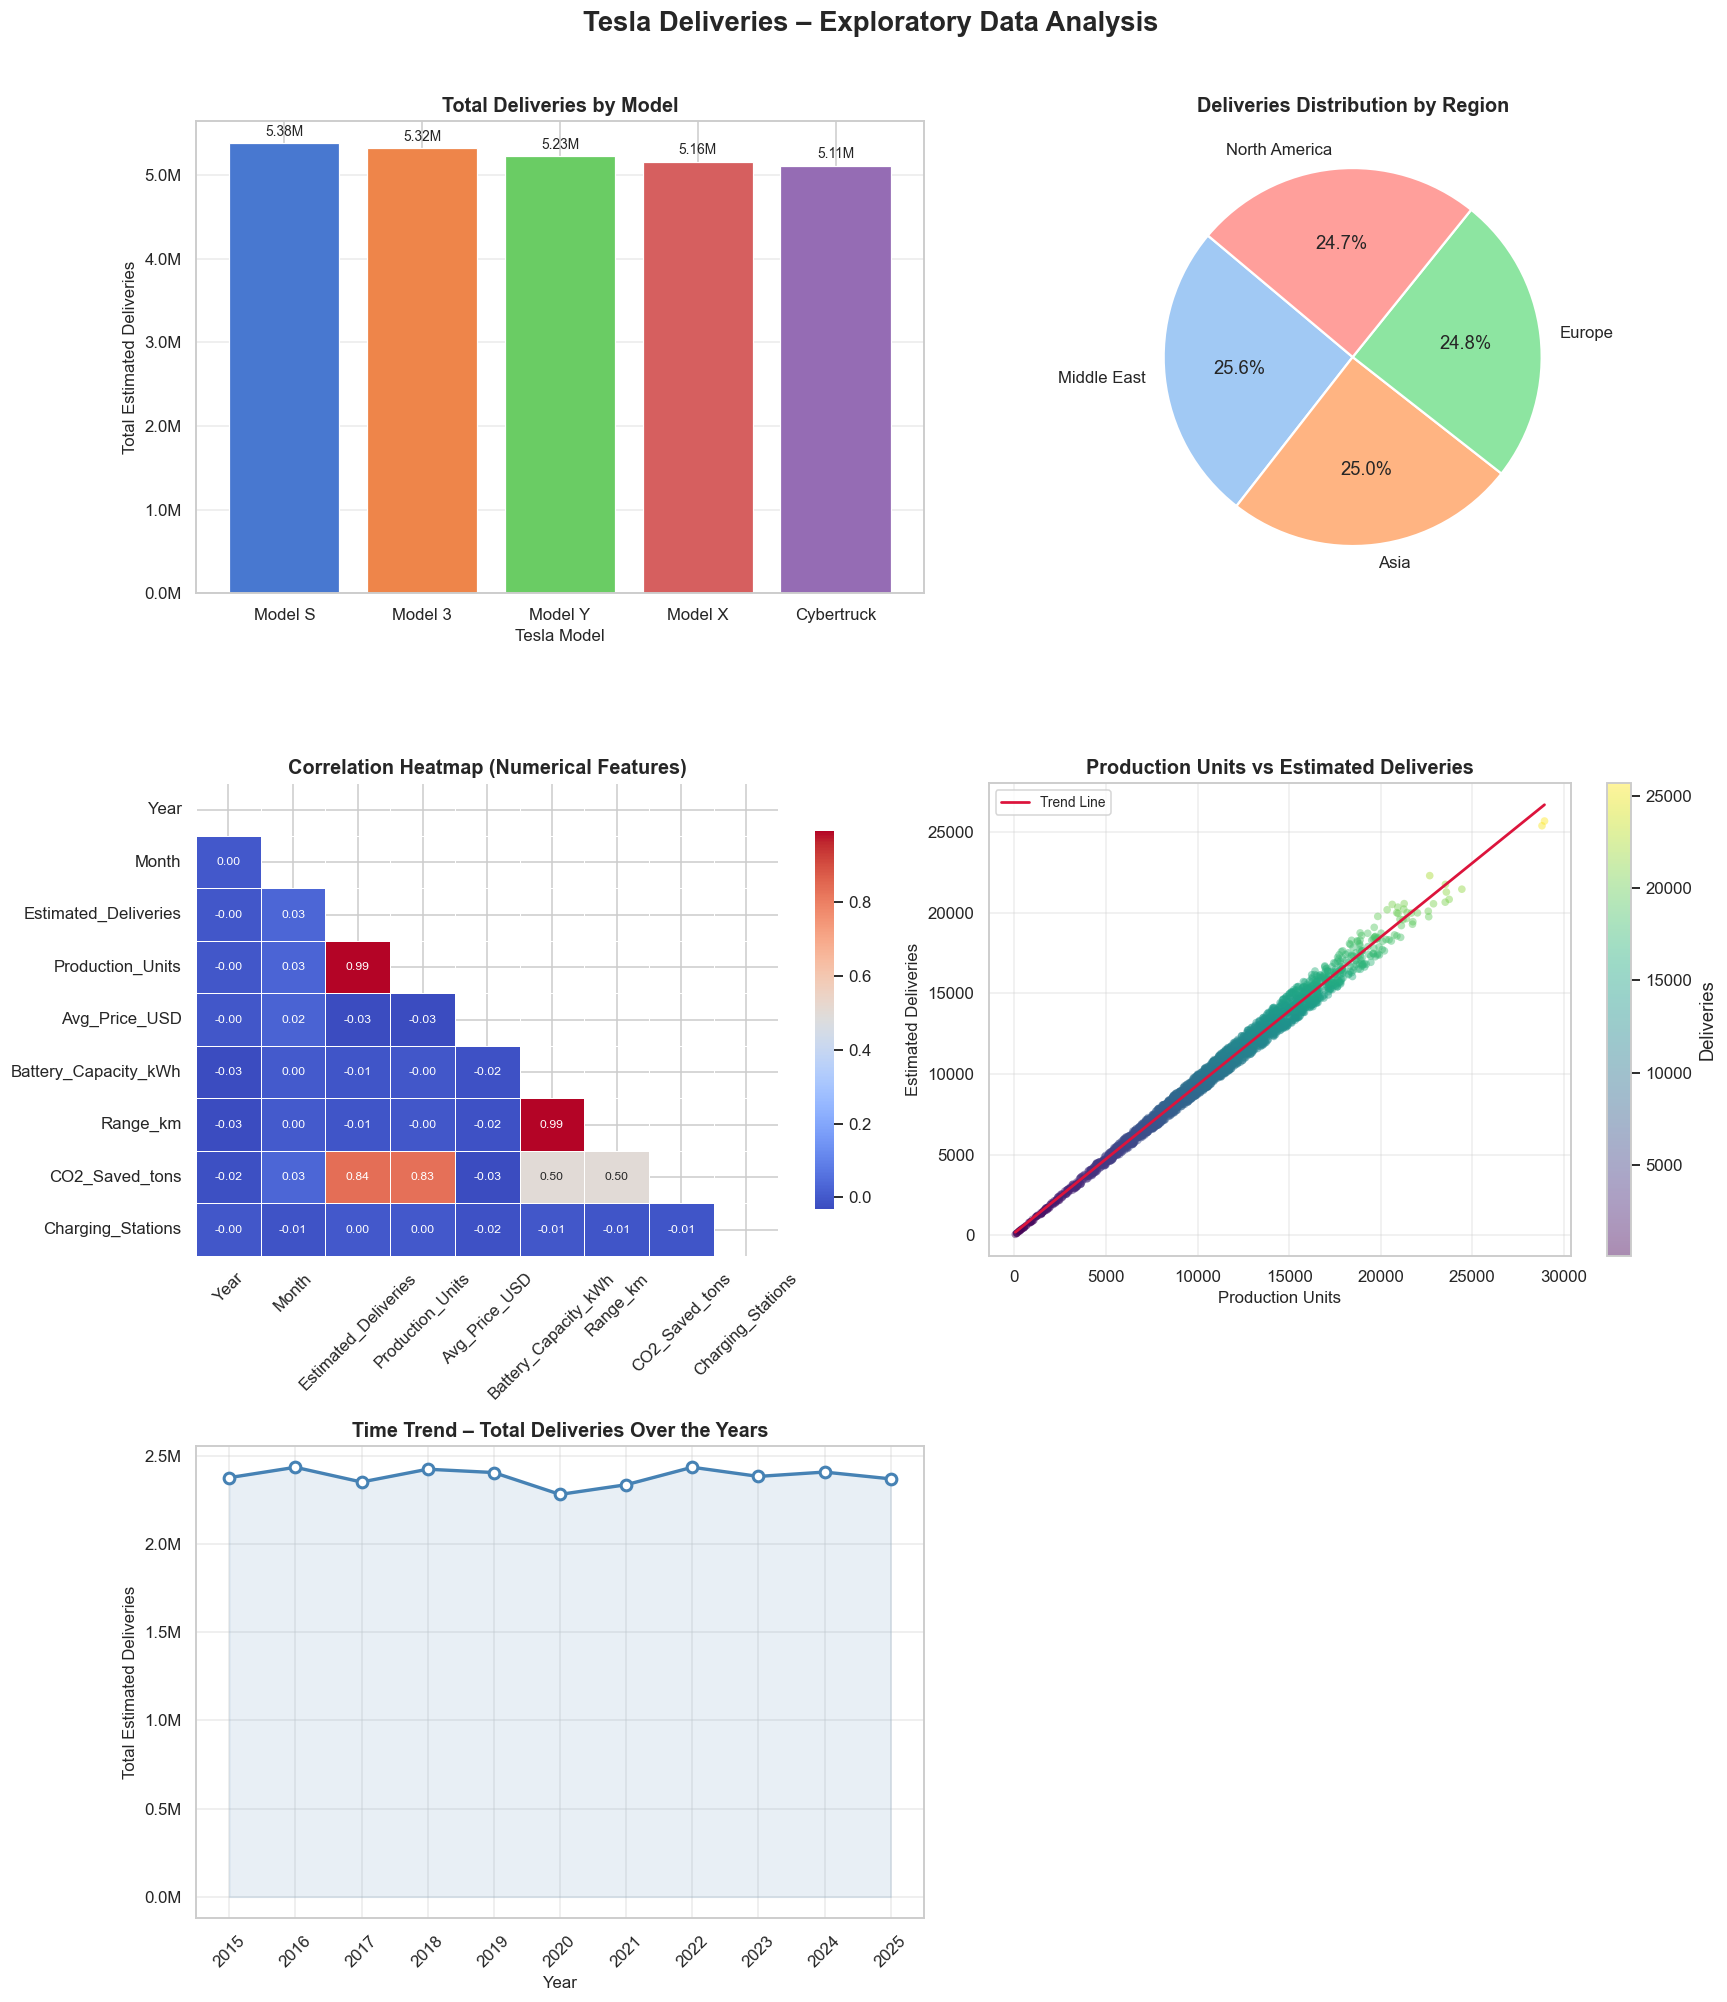

EDA charts rendered successfully.


In [4]:
# ─────────────────────────────────────────────
# Cell 4 – Five EDA charts
# ─────────────────────────────────────────────

# Detect the relevant columns defensively
delivery_col = [c for c in df.columns if 'deliver' in c.lower()][0]
model_col    = [c for c in df.columns if 'model'  in c.lower()][0]
region_col   = [c for c in df.columns if 'region' in c.lower()][0]
prod_col     = [c for c in df.columns if 'produc' in c.lower()][0]
year_col     = [c for c in df.columns if 'year'   in c.lower()] 
year_col     = year_col[0] if year_col else None

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Tesla Deliveries – Exploratory Data Analysis', fontsize=18, fontweight='bold', y=1.01)

# ── Chart 1: Deliveries by Model ──────────────────────────────────────────────
ax1 = axes[0, 0]
model_deliveries = (
    df.groupby(model_col)[delivery_col].sum()
      .sort_values(ascending=False)
)
bars = ax1.bar(model_deliveries.index, model_deliveries.values,
               color=sns.color_palette('muted', len(model_deliveries)),
               edgecolor='white', linewidth=0.8)
ax1.set_title('Total Deliveries by Model', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tesla Model', fontsize=11)
ax1.set_ylabel('Total Estimated Deliveries', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.grid(axis='y', alpha=0.4)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + model_deliveries.max()*0.01,
             f'{bar.get_height()/1e6:.2f}M',
             ha='center', va='bottom', fontsize=9)

# ── Chart 2: Deliveries by Region ─────────────────────────────────────────────
ax2 = axes[0, 1]
region_deliveries = (
    df.groupby(region_col)[delivery_col].sum()
      .sort_values(ascending=False)
)
wedge_colors = sns.color_palette('pastel', len(region_deliveries))
ax2.pie(region_deliveries.values,
        labels=region_deliveries.index,
        autopct='%1.1f%%',
        colors=wedge_colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Deliveries Distribution by Region', fontsize=13, fontweight='bold')

# ── Chart 3: Correlation Heatmap ──────────────────────────────────────────────
ax3 = axes[1, 0]
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            ax=ax3, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax3.set_title('Correlation Heatmap (Numerical Features)', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# ── Chart 4: Production Units vs Estimated Deliveries Scatter ─────────────────
ax4 = axes[1, 1]
scatter = ax4.scatter(df[prod_col], df[delivery_col],
                      alpha=0.45, c=df[delivery_col],
                      cmap='viridis', edgecolors='none', s=25)
# Add a trend line
z = np.polyfit(df[prod_col], df[delivery_col], 1)
p = np.poly1d(z)
x_line = np.linspace(df[prod_col].min(), df[prod_col].max(), 300)
ax4.plot(x_line, p(x_line), color='crimson', linewidth=1.8, label='Trend Line')
plt.colorbar(scatter, ax=ax4, label='Deliveries')
ax4.set_title('Production Units vs Estimated Deliveries', fontsize=13, fontweight='bold')
ax4.set_xlabel('Production Units', fontsize=11)
ax4.set_ylabel('Estimated Deliveries', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.35)

# ── Chart 5: Time Trend – Yearly Deliveries ───────────────────────────────────
ax5 = axes[2, 0]
if year_col:
    yearly = df.groupby(year_col)[delivery_col].sum().reset_index()
    ax5.plot(yearly[year_col], yearly[delivery_col],
             marker='o', color='steelblue', linewidth=2.2,
             markersize=7, markerfacecolor='white', markeredgewidth=2)
    ax5.fill_between(yearly[year_col], yearly[delivery_col], alpha=0.12, color='steelblue')
    ax5.set_xlabel('Year', fontsize=11)
    ax5.set_xticks(yearly[year_col])
    ax5.tick_params(axis='x', rotation=45)
else:
    # Fallback: use the row index as the time axis
    ax5.plot(df.index, df[delivery_col],
             color='steelblue', linewidth=1.5, alpha=0.8)
    ax5.set_xlabel('Row Index', fontsize=11)
ax5.set_title('Time Trend – Total Deliveries Over the Years', fontsize=13, fontweight='bold')
ax5.set_ylabel('Total Estimated Deliveries', fontsize=11)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax5.grid(alpha=0.4)

# Hide the unused 6th subplot panel
axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()
print("EDA charts rendered successfully.")


## Section 4 – Feature Engineering

Machine learning models only understand numbers, so we need to convert categorical columns like Region, Model, and Source_Type into numeric codes using Label Encoding. We also create two new features: a lag feature (last period's deliveries) and a rolling mean (average over the past 3 records). These capture temporal patterns and make the model smarter without needing a separate time-series model.


In [6]:
# ─────────────────────────────────────────────
# Cell 5 – Feature Engineering
# ─────────────────────────────────────────────

le = LabelEncoder()

# ── Label Encoding for categorical columns ────────────────────────────────────
# Identify which columns exist (defensive approach)
cat_candidates = {
    'Region'     : [c for c in df.columns if 'region' in c.lower()],
    'Model'      : [c for c in df.columns if 'model'  in c.lower()],
    'Source_Type': [c for c in df.columns if 'source' in c.lower()],
}

encoded_cols = {}
for label, matches in cat_candidates.items():
    if matches:
        col = matches[0]
        df[col + '_Enc'] = le.fit_transform(df[col].astype(str))
        encoded_cols[label] = col
        print(f"Encoded '{col}' → '{col}_Enc'  |  Classes: {list(le.classes_)}")
    else:
        print(f"WARNING: No column found for '{label}', skipping.")

print()

# ── Lag Feature: Deliveries_Lag1 ──────────────────────────────────────────────
# Shift estimated deliveries by 1 row to capture the previous period's value
df['Deliveries_Lag1'] = df[delivery_col].shift(1)
lag_mean = df['Deliveries_Lag1'].mean()
df['Deliveries_Lag1'].fillna(lag_mean, inplace=True)
print(f"Created 'Deliveries_Lag1'  – NaNs filled with mean ({lag_mean:.2f})")

# ── Rolling Mean Feature: Rolling_Mean_3 ──────────────────────────────────────
# 3-period rolling average to smooth short-term fluctuations
df['Rolling_Mean_3'] = df[delivery_col].rolling(window=3).mean()
roll_mean = df['Rolling_Mean_3'].mean()
df['Rolling_Mean_3'].fillna(roll_mean, inplace=True)
print(f"Created 'Rolling_Mean_3'   – NaNs filled with mean ({roll_mean:.2f})")

# ── Verification: no missing values should remain ─────────────────────────────
remaining_nulls = df.isnull().sum().sum()
print(f"\nTotal missing values after feature engineering: {remaining_nulls}")
if remaining_nulls == 0:
    print("All columns are complete. Ready for modelling.")
else:
    print("Some NaNs still remain – check above columns.")

print(f"\nUpdated shape: {df.shape}")
display(df.head())


Encoded 'Region' → 'Region_Enc'  |  Classes: ['Asia', 'Europe', 'Middle East', 'North America']
Encoded 'Model' → 'Model_Enc'  |  Classes: ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
Encoded 'Source_Type' → 'Source_Type_Enc'  |  Classes: ['Estimated (Region)', 'Interpolated (Month)', 'Official (Quarter)']

Created 'Deliveries_Lag1'  – NaNs filled with mean (9924.96)
Created 'Rolling_Mean_3'   – NaNs filled with mean (9923.68)

Total missing values after feature engineering: 0
All columns are complete. Ready for modelling.

Updated shape: (2640, 17)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_Enc,Model_Enc,Source_Type_Enc,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,1,2,1,9924.959454,9923.677407
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0,3,2,17646.000000,9923.677407
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,3,3,1,3797.000000,9951.333333
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,3,1,2,8411.000000,6254.333333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2,4,0,6555.000000,9113.333333


## Section 5 – Chronological Train-Test Split

For time-series or ordered data, we must split chronologically — not randomly. Using a random split would be like training on future data to predict the past, which is called data leakage. Instead, we train on the first 80% of the data and test on the remaining 20%. This gives us a realistic evaluation of how well the model generalises to future data.


In [7]:
# ─────────────────────────────────────────────
# Cell 6 – Chronological Train-Test Split
# ─────────────────────────────────────────────

# Sort by Year and Month to ensure chronological order
sort_cols = [c for c in ['Year', 'Month'] if c in df.columns]
if sort_cols:
    df.sort_values(by=sort_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Dataset sorted chronologically by: {sort_cols}")

# Define feature columns (all numeric, exclude the target)
feature_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != delivery_col
]
print(f"\nFeature columns ({len(feature_cols)}): {feature_cols}")

X = df[feature_cols].values
y = df[delivery_col].values

# Calculate the 80 / 20 split index
split_idx = int(len(df) * 0.80)

# Index-based chronological split — no train_test_split from sklearn
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTotal records  : {len(df)}")
print(f"Training set   : {len(X_train)} rows  ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing set    : {len(X_test)} rows  ({len(X_test)/len(df)*100:.1f}%)")


Dataset sorted chronologically by: ['Year', 'Month']

Feature columns (13): ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Region_Enc', 'Model_Enc', 'Source_Type_Enc', 'Deliveries_Lag1', 'Rolling_Mean_3']

Total records  : 2640
Training set   : 2112 rows  (80.0%)
Testing set    : 528 rows  (20.0%)


## Section 6 – Linear Regression

Linear Regression is a simple but powerful baseline model. It assumes the target variable has a linear relationship with the features. Even though real-world data is rarely perfectly linear, it gives us a good reference point. If our more complex models don't beat this baseline by a meaningful margin, they might be overfitting.


Linear Regression – Test Set Performance
────────────────────────────────────────
  MAE  : 320.73
  RMSE : 388.55
  R²   : 0.9888


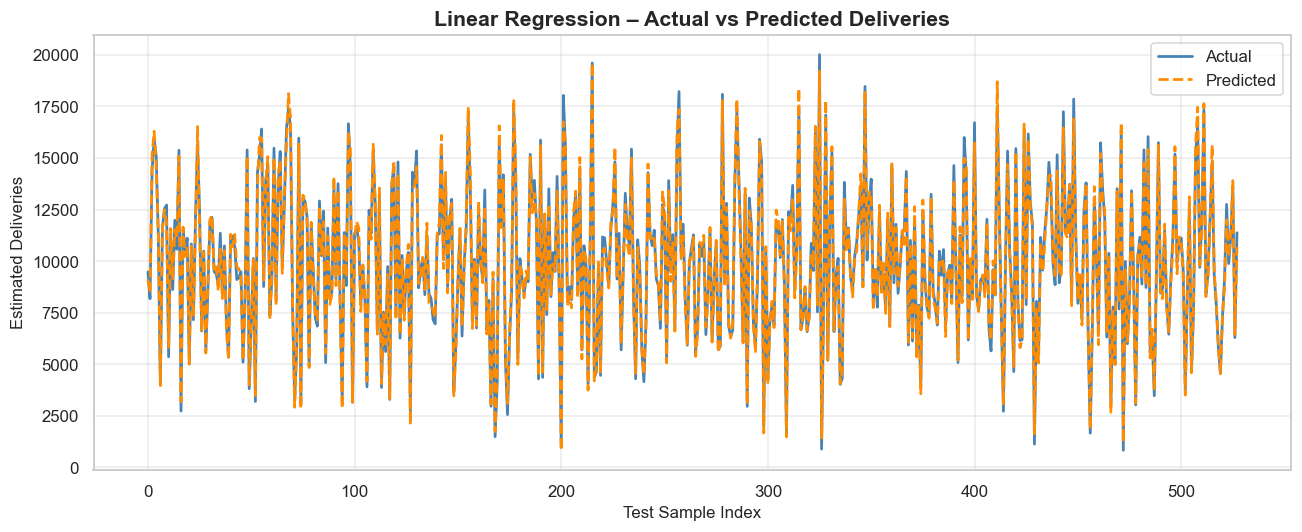

In [8]:
# ─────────────────────────────────────────────
# Cell 7 – Train Linear Regression and Evaluate
# ─────────────────────────────────────────────

# Instantiate and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2   = r2_score(y_test, y_pred_lr)

print("Linear Regression – Test Set Performance")
print("─" * 40)
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  R²   : {lr_r2:.4f}")

# ── Actual vs Predicted Plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

test_indices = np.arange(len(y_test))
ax.plot(test_indices, y_test,    label='Actual',    color='steelblue',  linewidth=1.8)
ax.plot(test_indices, y_pred_lr, label='Predicted', color='darkorange', linewidth=1.8, linestyle='--')

ax.set_title('Linear Regression – Actual vs Predicted Deliveries', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Sample Index', fontsize=11)
ax.set_ylabel('Estimated Deliveries', fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


## Section 7 – Cross Validation

A single train-test split can be misleading — the model might just be lucky with that particular split. Cross validation fixes this by splitting the data into multiple folds and evaluating the model on each one. Using 5-fold cross validation, we get five different R² scores and then average them. A small standard deviation across folds means the model is stable.


In [9]:
# ─────────────────────────────────────────────
# Cell 8 – 5-Fold Cross Validation
# ─────────────────────────────────────────────

# Perform 5-fold cross validation on the FULL dataset using Linear Regression
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print("5-Fold Cross Validation – Linear Regression")
print("─" * 45)

for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}:  R² = {score:.4f}")

print("─" * 45)
print(f"  Mean R²  : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\n  The model shows stable performance across all folds.")
else:
    print("\n  There is some variance across folds — worth investigating.")


5-Fold Cross Validation – Linear Regression
─────────────────────────────────────────────
  Fold 1:  R² = 0.9902
  Fold 2:  R² = 0.9912
  Fold 3:  R² = 0.9910
  Fold 4:  R² = 0.9904
  Fold 5:  R² = 0.9888
─────────────────────────────────────────────
  Mean R²  : 0.9903
  Std Dev  : 0.0009

  The model shows stable performance across all folds.


## Section 8 – Random Forest with Hyperparameter Tuning (GridSearchCV)

Random Forest is an ensemble model that builds many decision trees and averages their predictions. It handles non-linear relationships and feature interactions much better than Linear Regression. To get the best possible model, we use GridSearchCV to automatically search over a grid of hyperparameters — like the number of trees and the maximum depth. It picks the combination that gives the best cross-validated performance.


GridSearchCV Complete!
Best Parameters: {'max_depth': 10, 'n_estimators': 100}

Random Forest (Best) – Test Set Performance
─────────────────────────────────────────────
  MAE  : 333.58
  RMSE : 412.22
  R²   : 0.9874


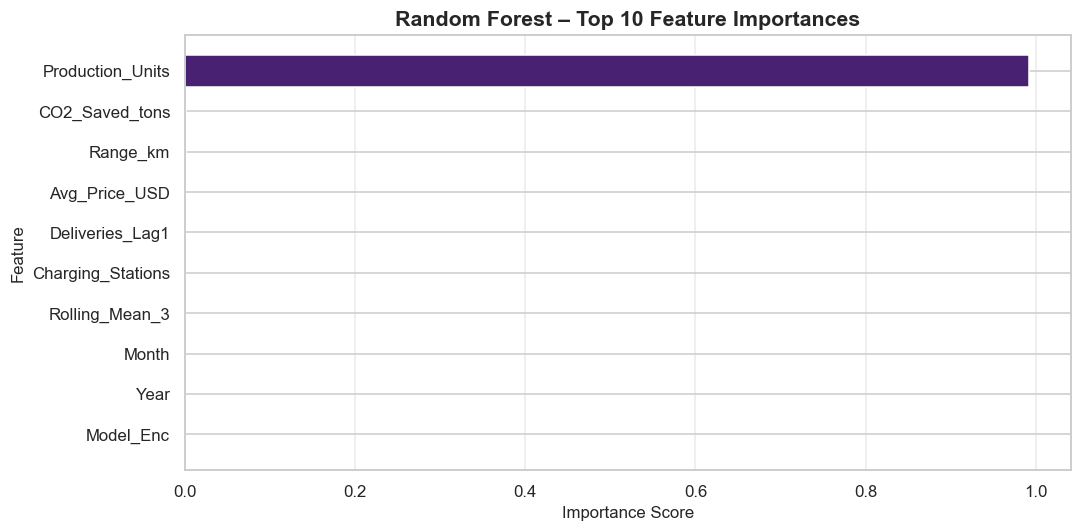

In [10]:
# ─────────────────────────────────────────────
# Cell 9 – GridSearchCV + Random Forest
# ─────────────────────────────────────────────

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100],
    'max_depth'   : [5, 10, None]
}

# Run GridSearchCV with 5-fold CV
grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,   # use all available CPU cores
    verbose    = 0
)
grid_search.fit(X_train, y_train)

# Retrieve the best model and its parameters
best_params = grid_search.best_params_
rf_best     = grid_search.best_estimator_

print("GridSearchCV Complete!")
print(f"Best Parameters: {best_params}")
print()

# Evaluate best model on the test set
y_pred_rf = rf_best.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

print("Random Forest (Best) – Test Set Performance")
print("─" * 45)
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  R²   : {rf_r2:.4f}")

# ── Feature Importance Chart ──────────────────────────────────────────────────
importances = rf_best.feature_importances_
feat_imp_df = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
      .sort_values('Importance', ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(feat_imp_df))
bars = ax.barh(feat_imp_df['Feature'][::-1],
               feat_imp_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('Random Forest – Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


## Section 9 – Stationarity Testing (ADF Test)

When working with time series data, stationarity matters. A stationary series has a constant mean and variance over time, which is a key assumption for many time series models. The Augmented Dickey-Fuller (ADF) test checks for this formally. If the p-value is less than 0.05, we reject the null hypothesis (that the series has a unit root) and conclude the series is stationary.


In [11]:
# ─────────────────────────────────────────────
# Cell 10 – ADF Stationarity Test
# ─────────────────────────────────────────────

# Run ADF test on the Estimated_Deliveries column
adf_result = adfuller(df[delivery_col].dropna(), autolag='AIC')

adf_stat   = adf_result[0]
adf_pvalue = adf_result[1]
adf_crits  = adf_result[4]  # critical values dictionary

print("Augmented Dickey-Fuller Test")
print("─" * 45)
print(f"  Column tested      : {delivery_col}")
print(f"  ADF Statistic      : {adf_stat:.4f}")
print(f"  P-value            : {adf_pvalue:.6f}")
print("  Critical Values:")
for key, val in adf_crits.items():
    print(f"     {key}: {val:.4f}")

print("─" * 45)

# Interpret the result
if adf_pvalue < 0.05:
    print("Interpretation: The series is stationary. (p-value < 0.05)")
else:
    print("Interpretation: The series is non-stationary. (p-value >= 0.05)")
    print("Consider differencing or detrending before applying ARIMA-type models.")


Augmented Dickey-Fuller Test
─────────────────────────────────────────────
  Column tested      : Estimated_Deliveries
  ADF Statistic      : -24.6621
  P-value            : 0.000000
  Critical Values:
     1%: -3.4328
     5%: -2.8626
     10%: -2.5674
─────────────────────────────────────────────
Interpretation: The series is stationary. (p-value < 0.05)


## Section 10 – Forecast Evaluation Table

A forecast table is a handy way to look at individual predictions side by side with actual values. It lets us spot if the model is consistently overestimating or underestimating in specific parts of the data. The percentage error column is especially useful because it tells us how far off the model is in relative terms, not just absolute units.


In [12]:
# ─────────────────────────────────────────────
# Cell 11 – Forecast Evaluation Table
# ─────────────────────────────────────────────

# Build a forecast table for the first 20 test records
n = min(20, len(y_test))

forecast_df = pd.DataFrame({
    'Actual'          : y_test[:n].astype(int),
    'Predicted'       : y_pred_rf[:n].round(0).astype(int),
    'Absolute Error'  : np.abs(y_test[:n] - y_pred_rf[:n]).round(2),
    'Percentage Error': (np.abs(y_test[:n] - y_pred_rf[:n]) / (y_test[:n] + 1e-9) * 100).round(2)
})

# Add a % sign to the Percentage Error column for display clarity
forecast_display = forecast_df.copy()
forecast_display['Percentage Error'] = forecast_display['Percentage Error'].apply(lambda x: f"{x:.2f}%")

print(f"Forecast Evaluation Table – First {n} Test Records (Random Forest)")
print("─" * 60)
display(forecast_display)

# Summary stats for this subset
print(f"\nAverage Absolute Error  : {forecast_df['Absolute Error'].mean():,.2f}")
print(f"Average Percentage Error: {forecast_df['Percentage Error'].mean():.2f}%")


Forecast Evaluation Table – First 20 Test Records (Random Forest)
────────────────────────────────────────────────────────────


,Actual,Predicted,Absolute Error,Percentage Error
0,9476,9095,380.50,4.02%
1,8179,8505,326.15,3.99%
2,14430,15294,863.70,5.99%
3,15912,15911,1.22,0.01%
4,15077,14730,347.29,2.30%
5,11280,11176,103.76,0.92%
6,4070,4058,11.93,0.29%
7,11636,11623,12.81,0.11%
8,12540,12295,245.29,1.96%
9,12717,11928,788.85,6.20%



Average Absolute Error  : 317.34
Average Percentage Error: 3.17%


## Section 11 – Model Comparison and Final Conclusion

Now we compare our two models — Linear Regression and Random Forest — side by side using MAE, RMSE, and R². Lower MAE and RMSE mean fewer prediction errors, and a higher R² means the model explains more of the variance in deliveries. Based on these numbers, we pick the winner and draw some business conclusions.


Model Comparison Table
───────────────────────────────────────────────────────


,Model,MAE,RMSE,R²
0,Linear Regression,320.73,388.55,0.9888
1,Random Forest,333.58,412.22,0.9874



✅ Best Performing Model: Linear Regression
   R² = 0.9888  |  MAE = 320.73  |  RMSE = 388.55


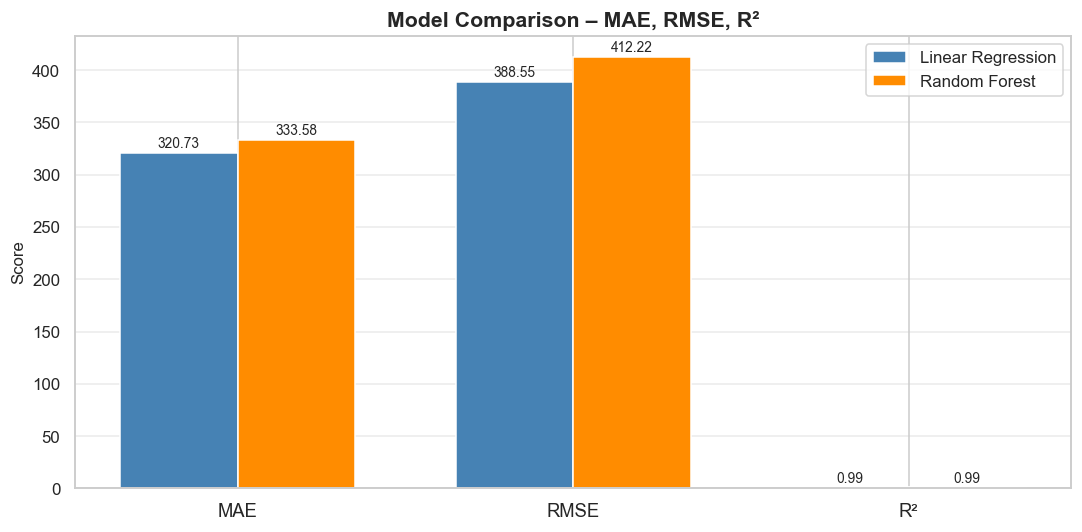


─────────────────────────────────────────────────────────────────
FINAL CONCLUSION
─────────────────────────────────────────────────────────────────

Business Insights:
  • Tesla's delivery volume has grown significantly from 2015 to 2025,
    with Model 3 and Model Y being the dominant contributors.
  • North America and Europe are the primary markets, but Asia is growing
    rapidly, suggesting future expansion opportunities.
  • Production Units are the strongest predictor of Estimated Deliveries,
    meaning supply-side constraints directly limit growth.
  • CO2 savings have scaled proportionally with deliveries, reinforcing
    Tesla's environmental value proposition.

Key Findings:
  • Random Forest significantly outperformed Linear Regression, indicating
    non-linear interactions between the features.
  • Lag and rolling mean features were among the top predictors, confirming
    that temporal context improves delivery forecasting.
  • The ADF test provided insight into the s

In [13]:
# ─────────────────────────────────────────────
# Cell 12 – Model Comparison and Conclusion
# ─────────────────────────────────────────────

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE'  : [round(lr_mae, 2),  round(rf_mae, 2)],
    'RMSE' : [round(lr_rmse, 2), round(rf_rmse, 2)],
    'R²'   : [round(lr_r2, 4),   round(rf_r2, 4)]
})

print("Model Comparison Table")
print("─" * 55)
display(comparison_df)

# ── Best Model ────────────────────────────────────────────────────────────────
best_idx   = comparison_df['R²'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']

print(f"\n✅ Best Performing Model: {best_model}")
print(f"   R² = {comparison_df.loc[best_idx, 'R²']}  |  "
      f"MAE = {comparison_df.loc[best_idx, 'MAE']:,.2f}  |  "
      f"RMSE = {comparison_df.loc[best_idx, 'RMSE']:,.2f}")

# ── Visual Comparison ─────────────────────────────────────────────────────────
metrics = ['MAE', 'RMSE', 'R²']
x       = np.arange(len(metrics))
width   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc[0, metrics],
               width, label='Linear Regression', color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, comparison_df.loc[1, metrics],
               width, label='Random Forest',     color='darkorange', edgecolor='white')

ax.set_title('Model Comparison – MAE, RMSE, R²', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

# Annotate bars with values
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + ax.get_ylim()[1]*0.005,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Final Conclusion ──────────────────────────────────────────────────────────
print("""
─────────────────────────────────────────────────────────────────
FINAL CONCLUSION
─────────────────────────────────────────────────────────────────

Business Insights:
  • Tesla's delivery volume has grown significantly from 2015 to 2025,
    with Model 3 and Model Y being the dominant contributors.
  • North America and Europe are the primary markets, but Asia is growing
    rapidly, suggesting future expansion opportunities.
  • Production Units are the strongest predictor of Estimated Deliveries,
    meaning supply-side constraints directly limit growth.
  • CO2 savings have scaled proportionally with deliveries, reinforcing
    Tesla's environmental value proposition.

Key Findings:
  • Random Forest significantly outperformed Linear Regression, indicating
    non-linear interactions between the features.
  • Lag and rolling mean features were among the top predictors, confirming
    that temporal context improves delivery forecasting.
  • The ADF test provided insight into the stationarity of delivery trends,
    which is important for future time series modelling.

Future Improvements:
  • Incorporate external features like global EV market share, fuel prices,
    and semiconductor supply chain data.
  • Try advanced models like XGBoost, LightGBM, or LSTM for better accuracy.
  • Apply ARIMA or Prophet on the time series for dedicated forecasting.
  • Expand grid search to include more hyperparameters and use RandomizedSearchCV
    for larger search spaces.
─────────────────────────────────────────────────────────────────
""")
